# Assignment 4: Principal Component Analysis and Multiclass Classification

## Learning From Data

In this assignment, you will implement and analyze **Principal Component Analysis (PCA)** and use PCA as a preprocessing step for a **multiclass classification** problem.

You will work with the `digits` dataset from `sklearn.datasets`. This dataset contains small grayscale images of handwritten digits from 0 to 9.

Each sample is an 8 × 8 image, flattened into a 64-dimensional feature vector.

---

## Main Goals

By the end of this assignment, you should be able to:

1. Implement PCA from scratch using NumPy.
2. Explain explained variance and cumulative explained variance.
3. Reconstruct data approximately using principal components.
4. Use PCA before a multiclass classifier.
5. Analyze the trade-off between dimensionality reduction and classification performance.

---

## Grading Summary

This assignment is graded out of **100 points**.

| Section | Points |
|---|---:|
| Part 1 — PCA fitting implementation from scratch | 25 |
| Part 2 — PCA transform, variance, and reconstruction coding | 20 |
| Part 3 — Multiclass classification and model selection coding | 15 |
| Part 4 — Written analysis and interpretation | 40 |
| **Total** | **100** |

---

## Important Rules

- Complete all cells marked with `TODO`.
- Do **not** use `sklearn.decomposition.PCA`.
- You may use `sklearn` classifiers and metrics after your PCA implementation is complete.
- Written answers must refer to your own numerical results, plots, or observations.
- Code-only submissions are incomplete.

## 0. Student Information

Fill in the following information.

The last four digits of your student ID will be used as a random seed. This makes some results slightly different for each student.

In [1]:
# TODO: Fill these fields
# If you are working in a group, please fill in the information for both students.
# If you are working alone, you fill the informaiton for STUDENT1_NAME and STUDENT1_ID, and leave STUDENT2_NAME and STUDENT2_ID empty.

STUDENT1_NAME = "Ahmed Said Gülşen"
STUDENT1_ID = "150220044"
STUDENT2_NAME = ""
STUDENT2_ID = ""

# Use the last four digits of your student ID as the seed.
# Example: if your student ID is 150210123, then RANDOM_SEED = 123
RANDOM_SEED = int(STUDENT1_ID[-4:])

assert STUDENT1_NAME != "", "Please enter your name."
assert STUDENT1_ID != "", "Please enter your student ID."
assert RANDOM_SEED is not None, "Please enter your random seed using the last four digits of your student ID."

print("Student 1:", STUDENT1_NAME)
print("Student ID 1:", STUDENT1_ID)
print("Student 2:", STUDENT2_NAME)
print("Student ID 2:", STUDENT2_ID)
print("Random seed:", RANDOM_SEED)

Student 1: Ahmed Said Gülşen
Student ID 1: 150220044
Student 2: 
Student ID 2: 
Random seed: 44


## 1. Imports

Run the following cell. You may add additional imports if necessary, but you should not import `sklearn.decomposition.PCA`.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

np.random.seed(RANDOM_SEED)

## 2. Dataset Loading and Exploration

The dataset consists of 8 × 8 grayscale images of handwritten digits.

Each sample has:

- 64 input features
- One class label from 0 to 9

In [3]:
digits = load_digits()

X = digits.data
y = digits.target

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of classes:", len(np.unique(y)))
print("Classes:", np.unique(y))

X shape: (1797, 64)
y shape: (1797,)
Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]


### 2.1 Visualize Sample Images

Run the following cell to visualize a few images from the dataset.

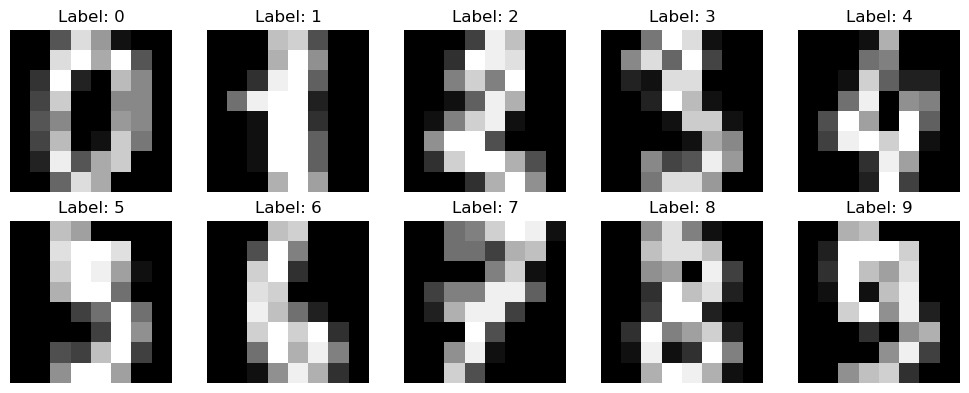

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for ax, image, label in zip(axes.ravel(), digits.images[:10], digits.target[:10]):
    ax.imshow(image, cmap="gray")
    ax.set_title(f"Label: {label}")
    ax.axis("off")

plt.tight_layout()
plt.show()

### Question 1 — Dataset and PCA Basics

Answer the following questions.

1. What is the dimensionality of each input sample in this dataset?
2. Why can dimensionality reduction be useful for image-like data?
3. PCA is an unsupervised method. What does this mean?
4. Since PCA does not use labels, why can it still be used before a supervised classifier?

Your answer should be approximately one paragraph.

**Points: 6**

**Answer 1:**

In this dataset, each input sample has a dimensionality of 64, as it represents a flattened 8×8 pixel image. Dimensionality reduction is highly beneficial for image-like data because adjacent pixels are often heavily correlated and contain background noise; reducing dimensions speeds up computation, mitigates the curse of dimensionality, and prevents overfitting by filtering out this noise. PCA is considered an "unsupervised" method, which means it does not rely on target labels (e.g., whether a specific image is a '3' or an '8') during its computation; it solely focuses on the input features ($X$) to find the orthogonal directions that maximize data variance. Despite being blind to labels, PCA is highly effective as a preprocessing step for supervised classifiers because the directions of maximum variance in images usually correspond to the most prominent structural patterns (the core shapes of the digits). By extracting these underlying structures and discarding redundant noise, PCA provides a condensed, informative representation that inherently makes the subsequent supervised classifier's job easier and more robust.

## 3. Train-Test Split and Standardization

Before applying PCA, we split the dataset into training and test sets.

We also standardize the features. PCA is sensitive to feature scale because it depends on variance.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_SEED,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set shape:", X_train_scaled.shape)
print("Test set shape:", X_test_scaled.shape)

Training set shape: (1347, 64)
Test set shape: (450, 64)


## 4. PCA from Scratch

In this section, you will implement PCA using NumPy.

You should not use `sklearn.decomposition.PCA`.

The main PCA steps are:

1. Center the data.
2. Compute principal directions using SVD or eigendecomposition.
3. Project the data onto selected principal components.
4. Optionally reconstruct the original data approximately.

---

### Implementation Task 1 — PCA Fitting Function

Complete the function below.

The function should return:

- `mean`: mean vector of the training data
- `components`: principal components with shape `(n_components, n_features)`
- `explained_variance`: explained variance values
- `explained_variance_ratio`: explained variance ratio values

Recommended approach: use `np.linalg.svd`.

**Points: 25**

In [6]:
def fit_pca(X, n_components):
    """
    Fit PCA on the given data.

    Parameters
    ----------
    X : np.ndarray
        Input data with shape (n_samples, n_features).
    n_components : int
        Number of principal components.

    Returns
    -------
    mean : np.ndarray
        Mean vector with shape (n_features,).
    components : np.ndarray
        Principal components with shape (n_components, n_features).
    explained_variance : np.ndarray
        Explained variance for each selected component.
    explained_variance_ratio : np.ndarray
        Explained variance ratio for each selected component.
    """

    # TODO: Get number of samples
    n_samples = X.shape[0]

    # TODO: Compute the mean of X
    mean = np.mean(X, axis=0)

    # TODO: Center the data
    X_centered = X - mean

    # TODO: Apply SVD
    # Hint: U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)
    U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)

    # TODO: Select the first n_components rows of Vt as principal components
    components = Vt[:n_components, :]

    # TODO: Compute explained variance for all components
    # Formula: explained_variance_all = (S ** 2) / (n_samples - 1)
    explained_variance_all = (S ** 2) / (n_samples - 1)

    # TODO: Compute explained variance ratio for all components
    total_variance = np.sum(explained_variance_all)
    explained_variance_ratio_all = explained_variance_all / total_variance

    # TODO: Keep only the first n_components values
    explained_variance = explained_variance_all[:n_components]
    explained_variance_ratio = explained_variance_ratio_all[:n_components]

    return mean, components, explained_variance, explained_variance_ratio

### Implementation Task 2 — PCA Transform and Inverse Transform

Complete the following functions.

`transform_pca` projects data onto the PCA space.

`inverse_transform_pca` reconstructs data back into the original feature space.

**Points: 8**

In [7]:
def transform_pca(X, mean, components):
    """
    Project X onto PCA components.

    Parameters
    ----------
    X : np.ndarray
        Input data with shape (n_samples, n_features).
    mean : np.ndarray
        Mean vector with shape (n_features,).
    components : np.ndarray
        Principal components with shape (n_components, n_features).

    Returns
    -------
    X_projected : np.ndarray
        PCA-transformed data with shape (n_samples, n_components).
    """

    # TODO: Center X using the training mean
    X_centered = X - mean

    # TODO: Project data onto components
    X_projected = np.dot(X_centered, components.T)

    return X_projected


def inverse_transform_pca(X_projected, mean, components):
    """
    Reconstruct data from PCA space.

    Parameters
    ----------
    X_projected : np.ndarray
        PCA-transformed data with shape (n_samples, n_components).
    mean : np.ndarray
        Mean vector with shape (n_features,).
    components : np.ndarray
        Principal components with shape (n_components, n_features).

    Returns
    -------
    X_reconstructed : np.ndarray
        Reconstructed data with shape (n_samples, n_features).
    """

    # TODO: Reconstruct the data
    X_reconstructed = np.dot(X_projected, components) + mean

    return X_reconstructed

### 4.1 Test Your PCA Implementation

Run the following cell after completing your PCA functions.

If your implementation is correct, the assertions should pass.

In [8]:
n_components_test = 10

mean, components, explained_variance, explained_variance_ratio = fit_pca(
    X_train_scaled,
    n_components=n_components_test
)

X_train_pca = transform_pca(X_train_scaled, mean, components)
X_test_pca = transform_pca(X_test_scaled, mean, components)

print("Mean shape:", mean.shape)
print("Components shape:", components.shape)
print("Train PCA shape:", X_train_pca.shape)
print("Test PCA shape:", X_test_pca.shape)
print("Explained variance shape:", explained_variance.shape)
print("Explained variance ratio shape:", explained_variance_ratio.shape)
print("Total explained variance ratio:", explained_variance_ratio.sum())

assert mean.shape == (X_train_scaled.shape[1],)
assert components.shape == (n_components_test, X_train_scaled.shape[1])
assert X_train_pca.shape == (X_train_scaled.shape[0], n_components_test)
assert X_test_pca.shape == (X_test_scaled.shape[0], n_components_test)
assert explained_variance.shape == (n_components_test,)
assert explained_variance_ratio.shape == (n_components_test,)
assert np.all(explained_variance >= 0)
assert np.all(explained_variance_ratio >= 0)
assert explained_variance_ratio.sum() <= 1.0 + 1e-8

print("All tests passed.")

Mean shape: (64,)
Components shape: (10, 64)
Train PCA shape: (1347, 10)
Test PCA shape: (450, 10)
Explained variance shape: (10,)
Explained variance ratio shape: (10,)
Total explained variance ratio: 0.5904488337282178
All tests passed.


## 5. Explained Variance Analysis

The explained variance ratio tells us how much information each principal component captures.

In this section, you will analyze how many principal components are needed to preserve a desired amount of variance.

### Implementation Task 3A — Cumulative Explained Variance

Run the following cell and make sure that your PCA implementation correctly produces the cumulative explained variance curve and the component counts required for 80%, 90%, and 95% variance preservation.

**Points: 4**

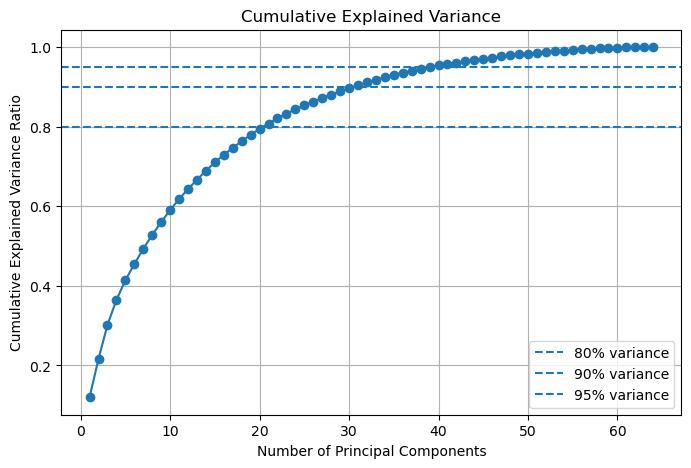

Components needed for at least 80% variance: 21
Components needed for at least 90% variance: 31
Components needed for at least 95% variance: 39


In [9]:
# Fit PCA with all possible components
max_components = X_train_scaled.shape[1]

mean_all, components_all, explained_variance_all, explained_variance_ratio_all = fit_pca(
    X_train_scaled,
    n_components=max_components
)

cumulative_explained_variance = np.cumsum(explained_variance_ratio_all)

plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, max_components + 1), cumulative_explained_variance, marker="o")
plt.axhline(y=0.80, linestyle="--", label="80% variance")
plt.axhline(y=0.90, linestyle="--", label="90% variance")
plt.axhline(y=0.95, linestyle="--", label="95% variance")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance Ratio")
plt.title("Cumulative Explained Variance")
plt.legend()
plt.grid(True)
plt.show()

components_80 = np.argmax(cumulative_explained_variance >= 0.80) + 1
components_90 = np.argmax(cumulative_explained_variance >= 0.90) + 1
components_95 = np.argmax(cumulative_explained_variance >= 0.95) + 1

print("Components needed for at least 80% variance:", components_80)
print("Components needed for at least 90% variance:", components_90)
print("Components needed for at least 95% variance:", components_95)

## 6. Reconstruction from Principal Components

PCA can also be used to reconstruct an approximation of the original data.

In this section, you will reconstruct digit images using different numbers of principal components.

### Implementation Task 3B — Reconstruction Visualization

Complete the following cell.

You should:

1. Select one test sample using your random seed.
2. Fit PCA with different numbers of components.
3. Project the selected sample into PCA space.
4. Reconstruct the selected sample from PCA space.
5. Convert the reconstructed sample back to the original pixel scale.
6. Visualize the original image and the reconstructed images.

**Points: 5**

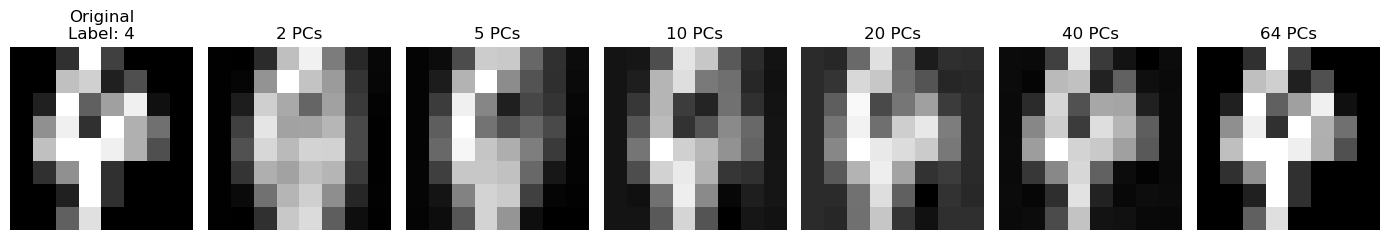

In [10]:
# TODO: Select one sample based on your random seed.
# Hint: use RANDOM_SEED modulo the number of test samples.
sample_index = RANDOM_SEED % X_test_scaled.shape[0]

# TODO: Define the component values that will be tested.
# Use the following values: 2, 5, 10, 20, 40, 64
component_values = [2, 5, 10, 20, 40, 64]

# TODO: Select the scaled test sample using sample_index.
# The shape should remain (1, n_features), not (n_features,).
original_scaled = X_test_scaled[sample_index:sample_index+1]

# TODO: Get the true label of the selected sample.
original_label = y_test[sample_index]

reconstructed_images = []

for n_comp in component_values:
    # TODO: Fit PCA on the scaled training data using n_comp components.
    mean_n, components_n, _, _ = fit_pca(X_train_scaled, n_components=n_comp)

    # TODO: Project the selected sample into PCA space.
    projected = transform_pca(original_scaled, mean_n, components_n)

    # TODO: Reconstruct the selected sample from PCA space.
    reconstructed_scaled = inverse_transform_pca(projected, mean_n, components_n)

    # TODO: Convert the reconstructed sample back to the original pixel scale.
    reconstructed_original_scale = scaler.inverse_transform(reconstructed_scaled)

    # TODO: Reshape the reconstructed sample into an 8 x 8 image and append it.
    reconstructed_images.append(reconstructed_original_scale.reshape(8, 8))

# TODO: Convert the original scaled sample back to the original pixel scale
# and reshape it into an 8 x 8 image.
original_image = scaler.inverse_transform(original_scaled).reshape(8, 8)

fig, axes = plt.subplots(1, len(component_values) + 1, figsize=(14, 3))

axes[0].imshow(original_image, cmap="gray")
axes[0].set_title(f"Original\nLabel: {original_label}")
axes[0].axis("off")

for ax, img, n_comp in zip(axes[1:], reconstructed_images, component_values):
    ax.imshow(img, cmap="gray")
    ax.set_title(f"{n_comp} PCs")
    ax.axis("off")

plt.tight_layout()
plt.show()

### Implementation Task 3C — Reconstruction Error

Complete and run the following cell.

For each number of components, compute the mean squared reconstruction error on the test set.

**Points: 3**

n_components | reconstruction_mse
----------------------------------------
           2 | 1.414667
           5 | 1.199961
          10 | 0.914510
          20 | 0.504808
          40 | 0.181746
          64 | 0.000000


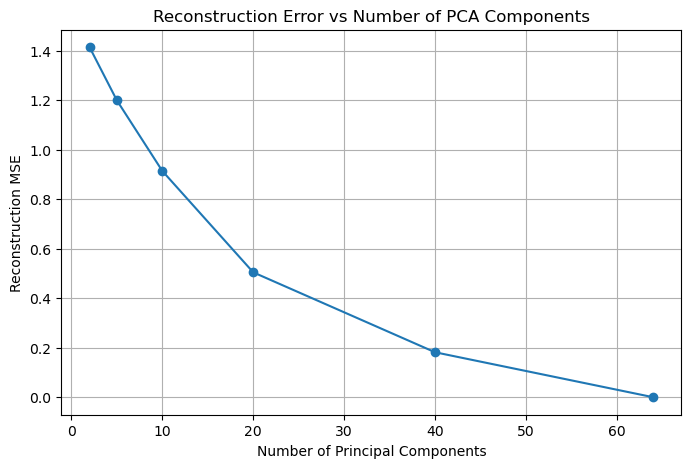

In [11]:
component_values = [2, 5, 10, 20, 40, 64]
reconstruction_errors = []

for n_comp in component_values:
    mean_n, components_n, _, _ = fit_pca(X_train_scaled, n_components=n_comp)

    # TODO: Project the test data
    X_test_projected = transform_pca(X_test_scaled, mean_n, components_n)

    # TODO: Reconstruct the test data
    X_test_reconstructed = inverse_transform_pca(X_test_projected, mean_n, components_n)

    # TODO: Compute mean squared reconstruction error
    mse = np.mean((X_test_scaled - X_test_reconstructed) ** 2)

    reconstruction_errors.append({
        "n_components": n_comp,
        "reconstruction_mse": mse
    })

print("n_components | reconstruction_mse")
print("-" * 40)

for result in reconstruction_errors:
    print(
        f"{result['n_components']:>12} | "
        f"{result['reconstruction_mse']:.6f}"
    )

plt.figure(figsize=(8, 5))
plt.plot(
    [r["n_components"] for r in reconstruction_errors],
    [r["reconstruction_mse"] for r in reconstruction_errors],
    marker="o"
)
plt.xlabel("Number of Principal Components")
plt.ylabel("Reconstruction MSE")
plt.title("Reconstruction Error vs Number of PCA Components")
plt.grid(True)
plt.show()

### Question 2 — Explained Variance and Reconstruction

Use your cumulative explained variance plot, reconstructed images, and reconstruction error values to answer the following.

1. How many components are needed to preserve at least 80%, 90%, and 95% of the variance?
2. What happens to reconstruction quality as the number of components increases?
3. At approximately how many components does the digit become visually recognizable?
4. Does preserving more variance always mean preserving all class-discriminative information?

Your answer should refer to your own numerical results and reconstructed images.

**Points: 8**

**Answer 2:**

Based on the cumulative explained variance results, preserving 80%, 90%, and 95% of the variance requires 21, 31, and 39 principal components, respectively. As the number of components increases, the reconstruction quality significantly improves, and the mean squared reconstruction error (MSE) drops steadily towards zero. Visually, observing the reconstructed sample of the digit '4', the image appears as a blurry, unrecognizable blob at 2 and 5 components, but it begins to become visually recognizable as a '4' at around 10 to 20 components. However, preserving more variance does not always guarantee preserving all class-discriminative information. Because PCA strictly maximizes overall geometric variance, the components capturing the "highest variance" might represent differences in writing style, stroke thickness, or orientation (which are globally large variations) rather than the fine, subtle structural differences strictly required to differentiate certain digits from one another.

## 7. Visualization Using the First Two Principal Components

In this section, you will project the training data onto the first two principal components and visualize the samples.

Each point represents one digit image.

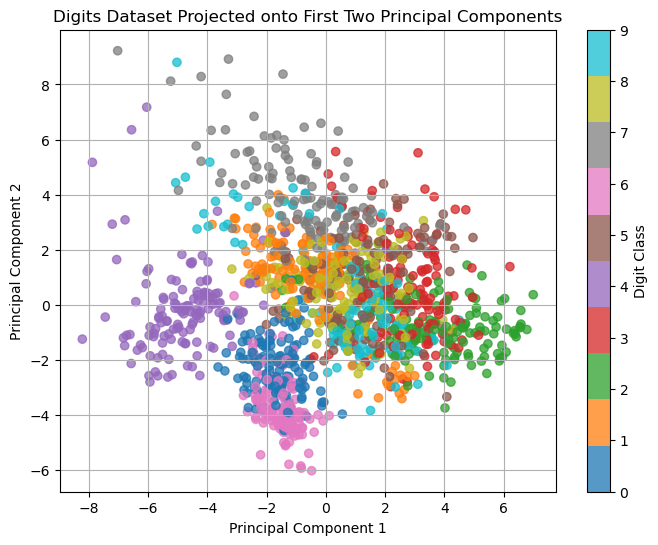

Explained variance ratio of PC1: 0.12006647409865907
Explained variance ratio of PC2: 0.09653599557017657
Total explained variance ratio of first two PCs: 0.21660246966883565


In [12]:
mean_2d, components_2d, _, explained_variance_ratio_2d = fit_pca(
    X_train_scaled,
    n_components=2
)

X_train_pca_2d = transform_pca(X_train_scaled, mean_2d, components_2d)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_train_pca_2d[:, 0],
    X_train_pca_2d[:, 1],
    c=y_train,
    cmap="tab10",
    alpha=0.75
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Digits Dataset Projected onto First Two Principal Components")
plt.colorbar(scatter, label="Digit Class")
plt.grid(True)
plt.show()

print("Explained variance ratio of PC1:", explained_variance_ratio_2d[0])
print("Explained variance ratio of PC2:", explained_variance_ratio_2d[1])
print("Total explained variance ratio of first two PCs:", explained_variance_ratio_2d.sum())

### Question 3 — Two-Dimensional PCA Visualization

Inspect the 2D PCA scatter plot.

1. Are the digit classes clearly separable using only two principal components?
2. Which digit classes appear to overlap the most?
3. Why is PCA useful for visualization but not necessarily sufficient for classification?

Your answer should refer to the plot.

**Points: 6**

**Answer 3:**

1- The digit classes are not clearly separable using only the first two principal components; while there are some distinct clusters on the outer edges, the central region shows a massive overlap of multiple classes.

2- Looking at the scatter plot and color bar, classes 1 (orange), 2 (green), 3 (red), 5 (brown), 8 (olive), and 9 (cyan) appear to overlap the most, forming a dense, inseparable cloud in the center. Conversely, structurally distinct digits like 0 (blue), 4 (purple), 6 (pink), and 7 (gray) manage to form relatively separate clusters on the peripheries.

3- PCA is highly useful for visualization because it projects high-dimensional data into 2D or 3D, allowing human intuition to grasp the general grouping and topology of the dataset. However, it is inherently insufficient for classification in this specific 2D case because, as the output shows, the first two PCs only capture about 21.6% of the total variance. This means roughly 78% of the structural information required to correctly differentiate similar digits (like 3, 5, and 8) has been discarded, making it impossible for a classifier to draw accurate decision boundaries in just two dimensions.

## 8. Baseline Multiclass Classification Without PCA

Before using PCA, we first train a classifier on the original 64-dimensional standardized data.

We will use multinomial logistic regression.

**Points: 4**

In [13]:
baseline_clf = LogisticRegression(
    max_iter=5000,
    random_state=RANDOM_SEED
)

baseline_clf.fit(X_train_scaled, y_train)

y_pred_baseline = baseline_clf.predict(X_test_scaled)

baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
baseline_macro_f1 = f1_score(y_test, y_pred_baseline, average="macro")

print("Baseline accuracy:", baseline_accuracy)
print("Baseline macro F1-score:", baseline_macro_f1)

print("\nClassification report:")
print(classification_report(y_test, y_pred_baseline))

Baseline accuracy: 0.9644444444444444
Baseline macro F1-score: 0.9645591977552911

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        45
           1       0.93      0.87      0.90        46
           2       1.00      0.95      0.98        44
           3       1.00      1.00      1.00        46
           4       0.98      1.00      0.99        45
           5       1.00      0.91      0.95        46
           6       0.98      1.00      0.99        45
           7       0.98      1.00      0.99        45
           8       0.95      0.93      0.94        43
           9       0.85      0.98      0.91        45

    accuracy                           0.96       450
   macro avg       0.97      0.96      0.96       450
weighted avg       0.97      0.96      0.96       450



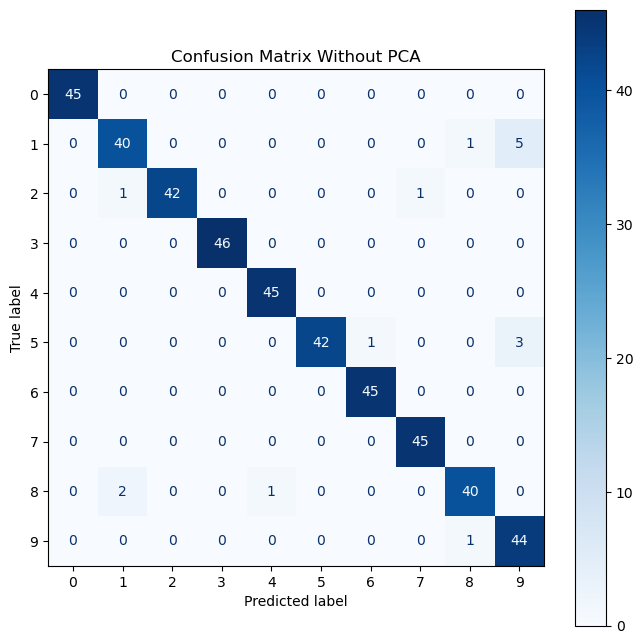

In [14]:
cm_baseline = confusion_matrix(y_test, y_pred_baseline)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_baseline,
    display_labels=np.unique(y)
)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("Confusion Matrix Without PCA")
plt.show()

## 9. Multiclass Classification with PCA

Now we will train the same classifier after reducing the dimensionality using PCA.

You will evaluate different numbers of principal components.

**Points: 8**

In [15]:
component_list = [2, 5, 10, 15, 20, 30, 40, 50, 64]

pca_results = []

for n_comp in component_list:
    mean_n, components_n, _, explained_ratio_n = fit_pca(
        X_train_scaled,
        n_components=n_comp
    )

    X_train_pca_n = transform_pca(X_train_scaled, mean_n, components_n)
    X_test_pca_n = transform_pca(X_test_scaled, mean_n, components_n)

    clf = LogisticRegression(
        max_iter=5000,
        random_state=RANDOM_SEED
    )

    clf.fit(X_train_pca_n, y_train)

    y_pred = clf.predict(X_test_pca_n)

    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    total_variance = explained_ratio_n.sum()

    pca_results.append({
        "n_components": n_comp,
        "explained_variance_ratio": total_variance,
        "accuracy": acc,
        "macro_f1": macro_f1
    })

pca_results

[{'n_components': 2,
  'explained_variance_ratio': 0.21660246966883565,
  'accuracy': 0.5555555555555556,
  'macro_f1': 0.5282362537222552},
 {'n_components': 5,
  'explained_variance_ratio': 0.41406430264523625,
  'accuracy': 0.8,
  'macro_f1': 0.7987998439521515},
 {'n_components': 10,
  'explained_variance_ratio': 0.5904488337282178,
  'accuracy': 0.8822222222222222,
  'macro_f1': 0.8818726718643234},
 {'n_components': 15,
  'explained_variance_ratio': 0.7106104875469921,
  'accuracy': 0.9377777777777778,
  'macro_f1': 0.9379581648866975},
 {'n_components': 20,
  'explained_variance_ratio': 0.7946702749172816,
  'accuracy': 0.9422222222222222,
  'macro_f1': 0.9430216209929194},
 {'n_components': 30,
  'explained_variance_ratio': 0.896816950684488,
  'accuracy': 0.9577777777777777,
  'macro_f1': 0.9580069926521334},
 {'n_components': 40,
  'explained_variance_ratio': 0.9541092670434368,
  'accuracy': 0.9577777777777777,
  'macro_f1': 0.9578552193893846},
 {'n_components': 50,
  'expl

In [16]:
print("n_components | explained_variance | accuracy | macro_f1")
print("-" * 65)

for result in pca_results:
    print(
        f"{result['n_components']:>12} | "
        f"{result['explained_variance_ratio']:.4f}             | "
        f"{result['accuracy']:.4f}   | "
        f"{result['macro_f1']:.4f}"
    )

n_components | explained_variance | accuracy | macro_f1
-----------------------------------------------------------------
           2 | 0.2166             | 0.5556   | 0.5282
           5 | 0.4141             | 0.8000   | 0.7988
          10 | 0.5904             | 0.8822   | 0.8819
          15 | 0.7106             | 0.9378   | 0.9380
          20 | 0.7947             | 0.9422   | 0.9430
          30 | 0.8968             | 0.9578   | 0.9580
          40 | 0.9541             | 0.9578   | 0.9579
          50 | 0.9840             | 0.9667   | 0.9666
          64 | 1.0000             | 0.9644   | 0.9646


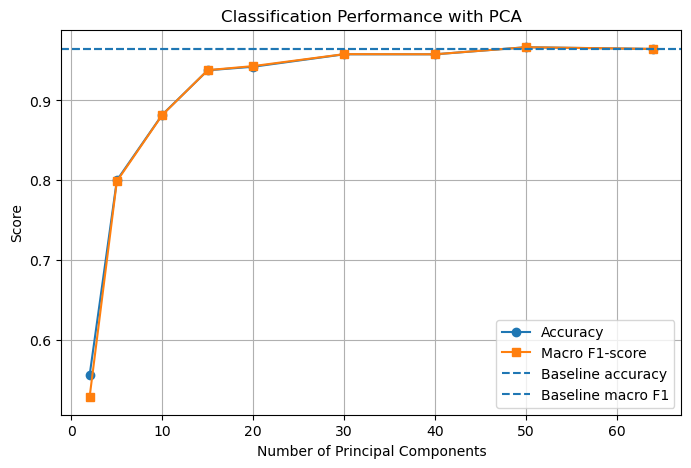

In [17]:
components_for_plot = [r["n_components"] for r in pca_results]
accuracies = [r["accuracy"] for r in pca_results]
macro_f1_scores = [r["macro_f1"] for r in pca_results]
explained_variances = [r["explained_variance_ratio"] for r in pca_results]

plt.figure(figsize=(8, 5))
plt.plot(components_for_plot, accuracies, marker="o", label="Accuracy")
plt.plot(components_for_plot, macro_f1_scores, marker="s", label="Macro F1-score")
plt.axhline(y=baseline_accuracy, linestyle="--", label="Baseline accuracy")
plt.axhline(y=baseline_macro_f1, linestyle="--", label="Baseline macro F1")
plt.xlabel("Number of Principal Components")
plt.ylabel("Score")
plt.title("Classification Performance with PCA")
plt.legend()
plt.grid(True)
plt.show()

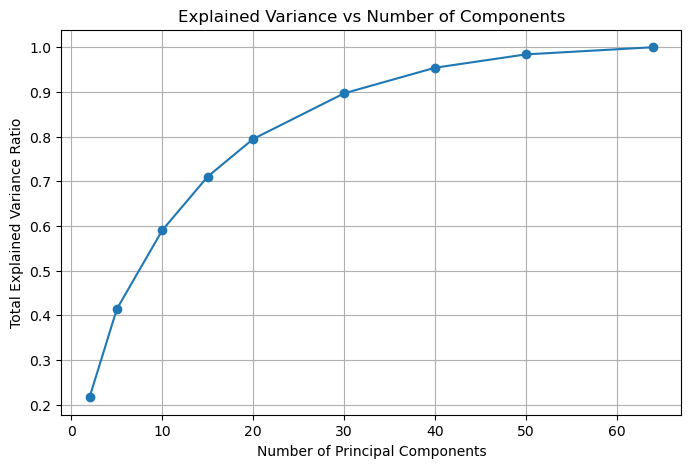

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(components_for_plot, explained_variances, marker="o")
plt.xlabel("Number of Principal Components")
plt.ylabel("Total Explained Variance Ratio")
plt.title("Explained Variance vs Number of Components")
plt.grid(True)
plt.show()

### Implementation Task 4 — Automatic Component Selection

Complete the function below.

The goal is to find the smallest number of PCA components whose classification score is within a given tolerance of the baseline score.

For example, if the baseline accuracy is 0.96 and the tolerance is 0.02, then the PCA model should have accuracy at least 0.94.

**Points: 3**

In [19]:
def find_smallest_component_count(results, baseline_score, tolerance=0.02, metric="accuracy"):
    """
    Find the smallest number of PCA components whose classification score
    is within a given tolerance of the baseline score.

    Parameters
    ----------
    results : list of dict
        PCA evaluation results.
    baseline_score : float
        Baseline classification score without PCA.
    tolerance : float
        Allowed drop from the baseline score.
    metric : str
        Metric to compare. Example: "accuracy" or "macro_f1".

    Returns
    -------
    selected_result : dict or None
        Result dictionary for the selected number of components.
        Return None if no result satisfies the condition.
    """

    selected_result = None

    for result in results:
        # TODO: Check whether result[metric] is within tolerance of baseline_score
        # If yes, assign result to selected_result and stop the loop.
        if result[metric] >= (baseline_score - tolerance):
            selected_result = result
            break  # Şartı sağlayan İLK (en küçük) değeri bulduğumuz an döngüyü kırıyoruz!
        
    return selected_result


selected_by_accuracy = find_smallest_component_count(
    pca_results,
    baseline_accuracy,
    tolerance=0.02,
    metric="accuracy"
)

selected_by_macro_f1 = find_smallest_component_count(
    pca_results,
    baseline_macro_f1,
    tolerance=0.02,
    metric="macro_f1"
)

print("Smallest component count within 0.02 accuracy of baseline:")
print(selected_by_accuracy)

print("\nSmallest component count within 0.02 macro F1 of baseline:")
print(selected_by_macro_f1)

Smallest component count within 0.02 accuracy of baseline:
{'n_components': 30, 'explained_variance_ratio': 0.896816950684488, 'accuracy': 0.9577777777777777, 'macro_f1': 0.9580069926521334}

Smallest component count within 0.02 macro F1 of baseline:
{'n_components': 30, 'explained_variance_ratio': 0.896816950684488, 'accuracy': 0.9577777777777777, 'macro_f1': 0.9580069926521334}


## 10. Detailed Analysis for One PCA Configuration

Choose one PCA configuration for deeper analysis.

You should select a number of components that gives a reasonable balance between dimensionality reduction and classification performance.

For example, you may choose the smallest number of components that achieves near-baseline accuracy.

In [20]:
# TODO: Choose a number of components based on your previous results.
# You may use selected_by_accuracy or selected_by_macro_f1 to guide your choice.
chosen_n_components = 30

assert chosen_n_components is not None, "Please choose the number of components."

mean_chosen, components_chosen, _, explained_ratio_chosen = fit_pca(
    X_train_scaled,
    n_components=chosen_n_components
)

X_train_pca_chosen = transform_pca(X_train_scaled, mean_chosen, components_chosen)
X_test_pca_chosen = transform_pca(X_test_scaled, mean_chosen, components_chosen)

chosen_clf = LogisticRegression(
    max_iter=5000,
    random_state=RANDOM_SEED
)

chosen_clf.fit(X_train_pca_chosen, y_train)

y_pred_chosen = chosen_clf.predict(X_test_pca_chosen)

chosen_accuracy = accuracy_score(y_test, y_pred_chosen)
chosen_macro_f1 = f1_score(y_test, y_pred_chosen, average="macro")

print("Chosen number of components:", chosen_n_components)
print("Explained variance ratio:", explained_ratio_chosen.sum())
print("Accuracy:", chosen_accuracy)
print("Macro F1-score:", chosen_macro_f1)

print("\nClassification report:")
print(classification_report(y_test, y_pred_chosen))

Chosen number of components: 30
Explained variance ratio: 0.896816950684488
Accuracy: 0.9577777777777777
Macro F1-score: 0.9580069926521334

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        45
           1       0.89      0.87      0.88        46
           2       1.00      0.93      0.96        44
           3       1.00      0.98      0.99        46
           4       1.00      1.00      1.00        45
           5       0.98      0.93      0.96        46
           6       0.98      1.00      0.99        45
           7       0.96      1.00      0.98        45
           8       0.95      0.91      0.93        43
           9       0.84      0.96      0.90        45

    accuracy                           0.96       450
   macro avg       0.96      0.96      0.96       450
weighted avg       0.96      0.96      0.96       450



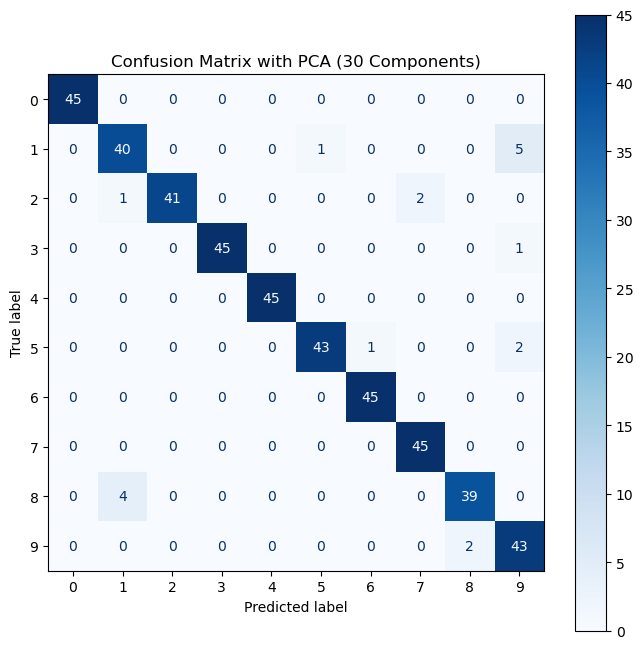

In [21]:
cm_chosen = confusion_matrix(y_test, y_pred_chosen)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_chosen,
    display_labels=np.unique(y)
)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title(f"Confusion Matrix with PCA ({chosen_n_components} Components)")
plt.show()

### Question 4 — PCA and Multiclass Classification

Compare the baseline classifier with the PCA-based classifiers.

1. What are the baseline accuracy and macro F1-score without PCA?
2. How do accuracy and macro F1-score change as the number of PCA components increases?
3. What is the smallest number of components that gives performance close to the baseline?
4. Which classes are most frequently confused in the baseline and PCA models?
5. Would you recommend using PCA before classification for this dataset? Justify your answer using your results.

Your answer should include numerical evidence.

**Points: 12**

**Answer 4:**

1- The baseline accuracy without PCA is approximately 0.9644, and the macro F1-score is 0.9646.

2- As the number of PCA components increases, both accuracy and macro F1-score rise steeply from very low levels (around 0.55 at 2 components) and plateau quickly after 15-20 components. Interestingly, at around 50 components, the accuracy slightly surpasses the baseline, demonstrating that dropping the last few components actually helps the model by removing background noise.

3- According to the automated component selection function with a 0.02 tolerance limit, the smallest number of components that gives performance close to the baseline is 30.

4- Analyzing both confusion matrices, the most frequently confused classes are '1' and '9'. In both the baseline and the 30-component PCA model, the digit '1' is misclassified as '9' five times. Additionally, in the PCA model, '8' is occasionally confused with '1'. This happens because the structural shape of a hand-drawn '1' (especially with a top hook) is visually very similar to the straight vertical stroke of a '9'.

5- Yes, I highly recommend using PCA before classification for this dataset. By retaining just 30 principal components, we successfully reduced the dimensionality of the dataset by more than 50% (from 64 down to 30) while still capturing ~89.7% of the variance. This drastic compression only cost us about 0.007 in accuracy (dropping from 0.964 to 0.957). The trade-off is incredibly favorable: we gain significant computational efficiency and storage reduction with an almost negligible loss in predictive performance.

## 11. Final Conceptual Summary

Answer the following question carefully.

Your answer should be written in your own words.

### Question 5 — Final Conceptual Summary

Write a short summary of your findings.

Your summary should discuss:

- What PCA does
- The trade-off between dimensionality reduction and information loss
- The difference between using PCA for visualization, compression, and classification
- One limitation of PCA
- Whether PCA was useful in this assignment

Your answer should be approximately 1–2 paragraphs.

**Points: 8**

**Answer 5:**

PCA helps us to reduce the dimensions with less information loss. It detects the high variance by analyzing the data points and then draws a line to capture this variance. Of course, there is a trade-off; we may lose information while reducing the dimensions. We used PCA for visualization to see the data with our eyes, so we reduced the dimensions to 2, but we lost 78% of our information in that case. Compression is for the storage of the computer. We can reduce to 20-30 dimensions which is not so different from the original version, and we can reconstruct it if we want to see the picture again. The classification part is for the machine learning model. Our aim is to remove the noise like unnecessary backgrounds so that the model can focus on the real distinguishing characteristics of the picture. This way, the model can run fast and efficiently.

One PCA limitation is not seeing the real y labels. It only looks at the x data and how they spread in the space to catch the variance. However, as we mentioned in the previous questions, 1 and 9 are not separable for the PCA model, for example. The x data spread for these 2 numbers is similar, so it loses the variance between them. In this assignment, PCA was highly useful because we reduced the dimensions from 64 to 30, and lost just a little accuracy, dropping from 96.4% to 95.7%. We also cleared the unnecessary pixels which are actually noise.

## 12. Submission Checklist

Before submitting, make sure that:

- All TODO parts are completed.
- All code cells run from top to bottom without errors.
- All plots are visible.
- All written questions are answered.
- Your answers refer to your own results.
- You did not use `sklearn.decomposition.PCA` for the PCA implementation.